Mutual Fund Analytics - Exploratory Data Analysis (EDA)

Objective
Analyze the cleaned mutual fund datasets and generate visualizations to identify trends and insights.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/05_category_inflows.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")
investor = pd.read_csv("../data/processed/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

Task 1: NAV Trend Analysis

Visualize the daily NAV trend for all 40 mutual fund schemes from 2022 to 2026. Highlight the 2023 bull run and the 2024 market correction.

In [3]:
nav.head()
nav.info()


<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [4]:
nav.shape

(46000, 3)

In [5]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
fund_master = pd.read_csv("../data/processed/01_fund_master.csv")

In [7]:
fund_master.head()


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [8]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [9]:
nav["amfi_code"] = nav["amfi_code"].astype(str)
fund_master["amfi_code"] = fund_master["amfi_code"].astype(str)

nav = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [10]:
nav.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [11]:
nav["date"] = pd.to_datetime(nav["date"])

In [12]:
nav = nav.sort_values(["scheme_name", "date"])

In [13]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of 40 Mutual Fund Schemes (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="2024 Market Correction"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Date",
    yaxis_title="NAV",
    width=1400,
    height=800,
)


fig.show()

In [14]:
fig.write_image("../reports/nav_trend_analysis.png")

Insight 1

- The NAV values of the selected mutual fund schemes generally show an upward trend over the period 2022–2026.
- The highlighted 2023 period represents a strong market rally, while the highlighted 2024 period marks phases of market correction.
- Despite short-term fluctuations, most schemes demonstrate long-term growth in NAV.

Task 2: AUM Growth Analysis

Objective:Visualize the yearly AUM growth of different fund houses from 2022 to 2025 and highlight SBI's market dominance.

In [15]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [16]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [17]:
aum.shape

(90, 5)

In [18]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [19]:
aum["date"] = pd.to_datetime(aum["date"])

In [20]:
aum["year"] = aum["date"].dt.year

In [21]:
aum = aum[(aum["year"] >= 2022) & (aum["year"] <= 2025)]

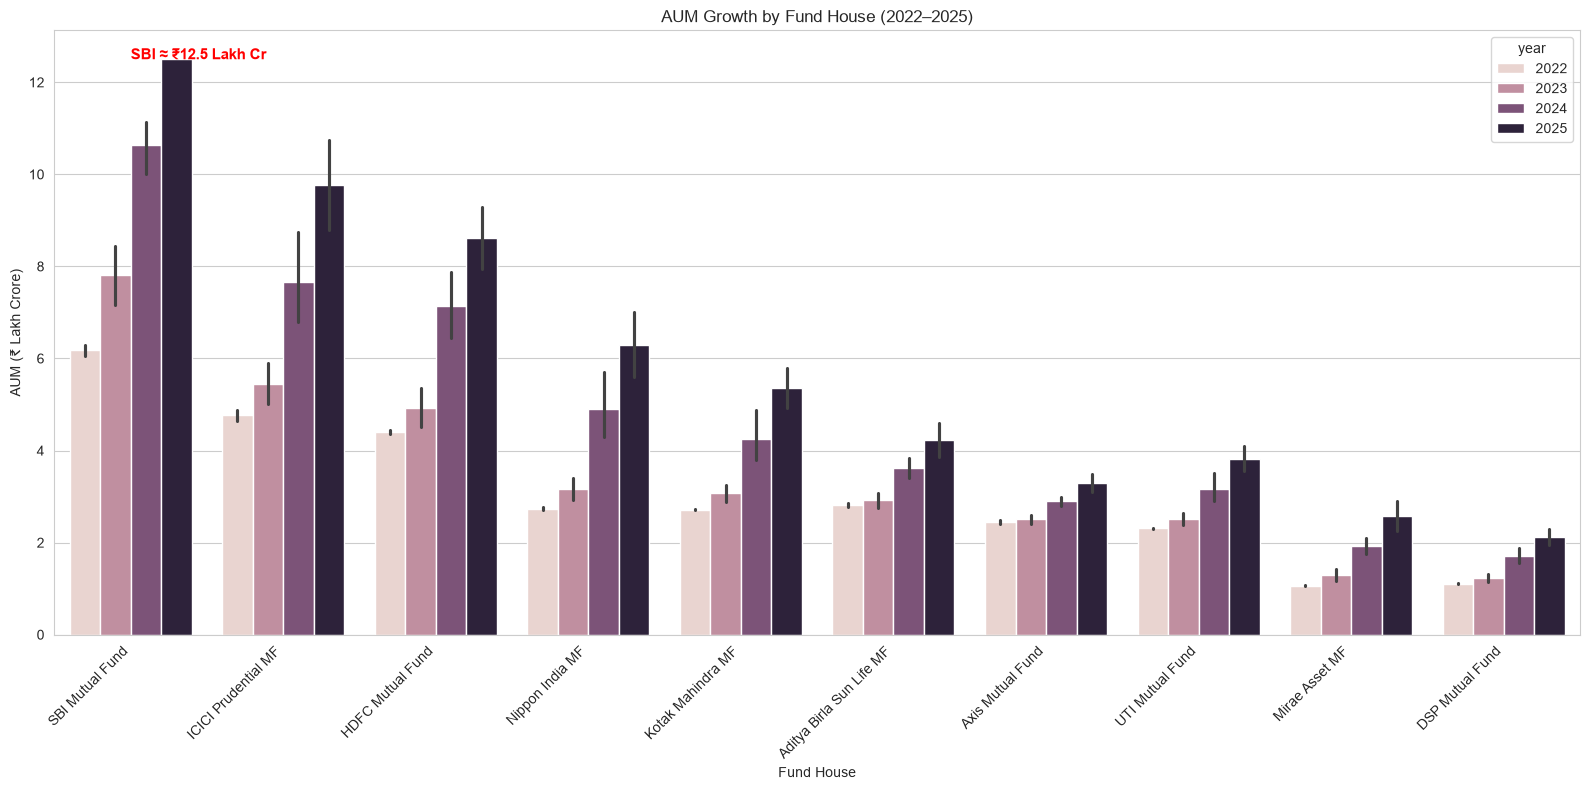

In [22]:
plt.figure(figsize=(16, 8))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.text(
    x=0,
    y=12.5,
    s="SBI ≈ ₹12.5 Lakh Cr",
    fontsize=11,
    color="red",
    fontweight="bold"
)

plt.savefig("../reports/aum_growth_bar_chart.png", dpi=300, bbox_inches="tight")

plt.show()

plt.close()

In [23]:
aum.shape

(90, 6)

In [24]:
aum["year"].value_counts()

year
2024    30
2022    20
2023    20
2025    20
Name: count, dtype: int64

In [25]:
aum[aum["fund_house"].str.contains("SBI", case=False)]

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
10,2022-09-30,SBI Mutual Fund,6.30,630000,186,2022
20,2023-03-31,SBI Mutual Fund,7.17,717000,186,2023
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025


In [26]:
aum[aum["aum_lakh_crore"] >= 12]

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
70,2025-03-31,SBI Mutual Fund,12.5,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.5,1250000,186,2025


In [27]:
aum["fund_house"].unique()

<StringArray>
[         'SBI Mutual Fund',      'ICICI Prudential MF',
         'HDFC Mutual Fund',          'Nippon India MF',
        'Kotak Mahindra MF', 'Aditya Birla Sun Life MF',
         'Axis Mutual Fund',          'UTI Mutual Fund',
           'Mirae Asset MF',          'DSP Mutual Fund']
Length: 10, dtype: str

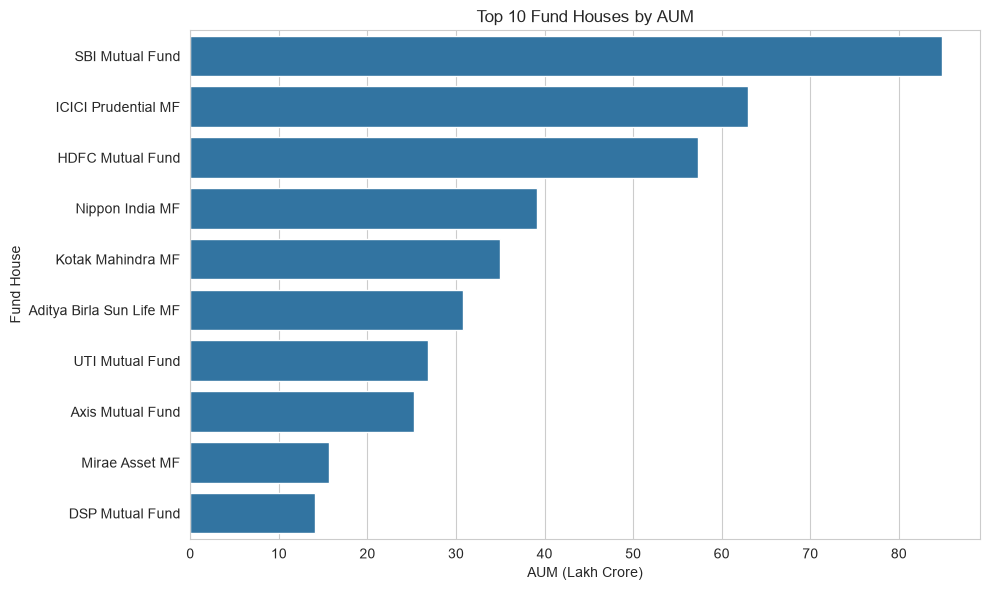

In [28]:
top_aum = aum.groupby("fund_house")["aum_lakh_crore"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_aum.values, y=top_aum.index)
plt.title("Top 10 Fund Houses by AUM")
plt.xlabel("AUM (Lakh Crore)")
plt.ylabel("Fund House")

plt.tight_layout()
plt.savefig("../reports/top10_fund_houses_aum.png", dpi=300)
plt.show()

Task 3: SIP Inflow Time Series

Objective:Analyze the monthly SIP inflow trend from January 2022 to December 2025 and highlight the all-time high SIP inflow of ₹31,002 Cr in December 2025.

In [29]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [30]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [31]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [32]:
sip["month"] = pd.to_datetime(sip["month"])

In [33]:
sip_filtered = sip[
    (sip["month"] >= "2022-01-01") &
    (sip["month"] <= "2025-12-31")
].copy()

In [34]:
max_row = sip_filtered.loc[
    sip_filtered["sip_inflow_crore"].idxmax()
]

In [35]:
import plotly.express as px

fig = px.line(
    sip_filtered,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)"
)

In [36]:
fig.add_annotation(
    x=max_row["month"].strftime("%Y-%m-%d"),
    y=float(max_row["sip_inflow_crore"]),
    text=f"₹{max_row['sip_inflow_crore']:,.0f} Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2,
    ax=-40,
    ay=-60,
    bgcolor="yellow"
)
fig.update_layout(
    template="plotly_white",
    width=1400,
    height=700,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)
fig.write_image("../reports/sip_inflow_trend.png")

fig.show()

In [37]:
import plotly
print(plotly.__version__)

6.9.0


In [38]:
sip.tail()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
43,2025-08-01,28265,8.85,9.80,15.18,20.04
44,2025-09-01,29361,9.00,10.50,15.38,19.80
45,2025-10-01,29529,9.10,9.45,15.55,16.61
46,2025-11-01,30200,9.20,9.10,15.72,19.27
47,2025-12-01,31002,9.35,9.80,15.90,17.17


In [39]:
fig = px.line(
    sip,
    x="month",
    y="active_sip_accounts_crore",
    title="Active SIP Accounts Trend (2022–2025)"
)

fig.write_image("../reports/active_sip_accounts.png")
fig.show()

Task 4: Category Inflow Heatmap

Objective: Visualize monthly net inflows across different mutual fund categories using a heatmap.

In [40]:
category.head()


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [41]:
category.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [42]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [43]:
category["month"]=pd.to_datetime(category["month"])

In [44]:
category["month"] = category["month"].dt.strftime("%b-%Y")

In [45]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

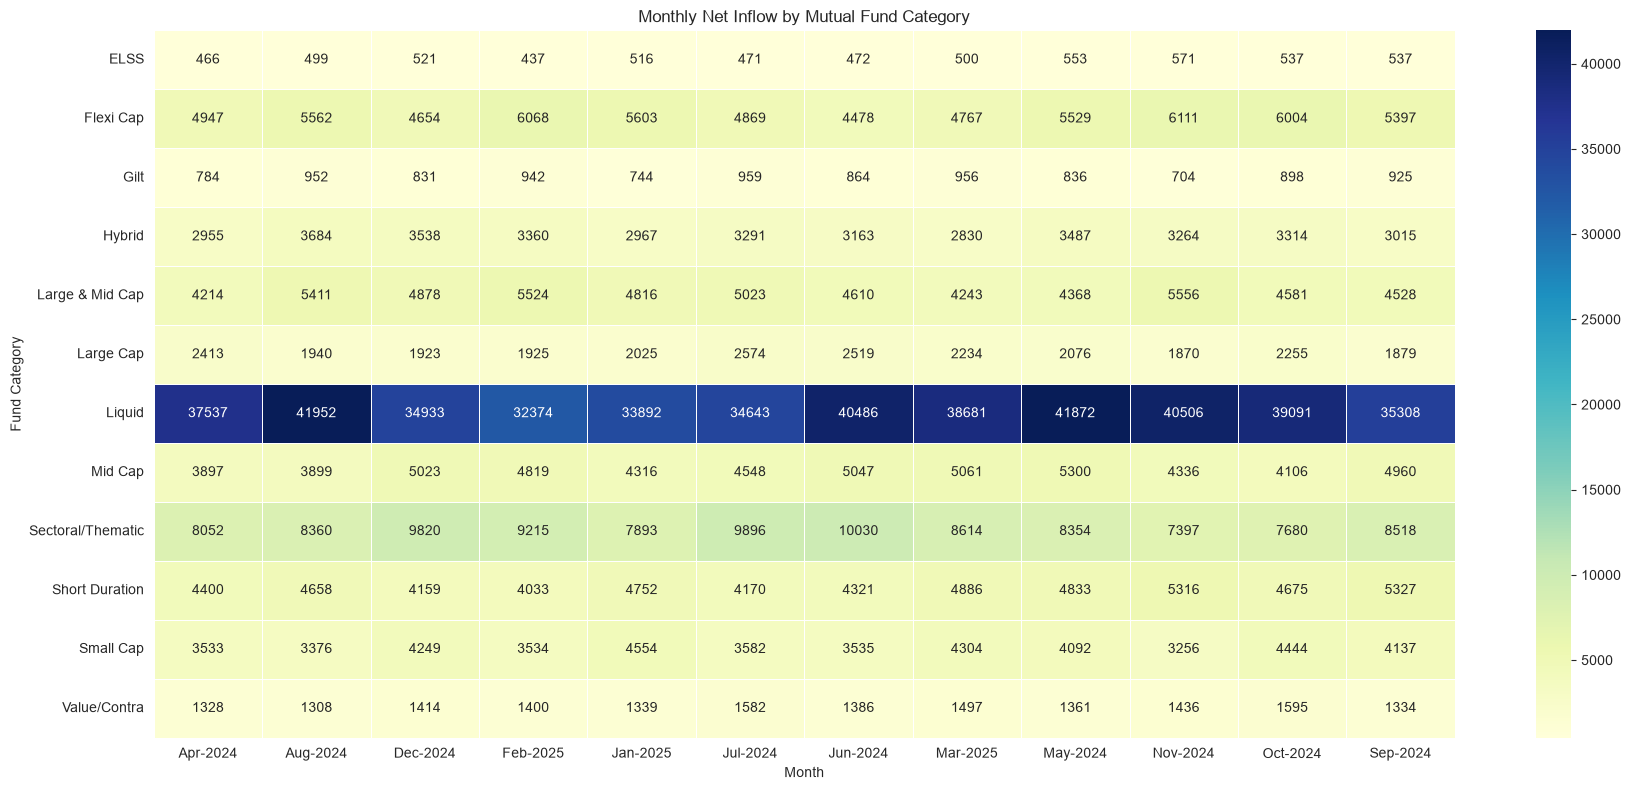

In [46]:
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Monthly Net Inflow by Mutual Fund Category")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../reports/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Task 5: Investor Demographics

Objective:Analyze investor demographics using age group distribution, SIP investment amounts by age group, and gender distribution.

In [47]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [48]:
investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [49]:
investor.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


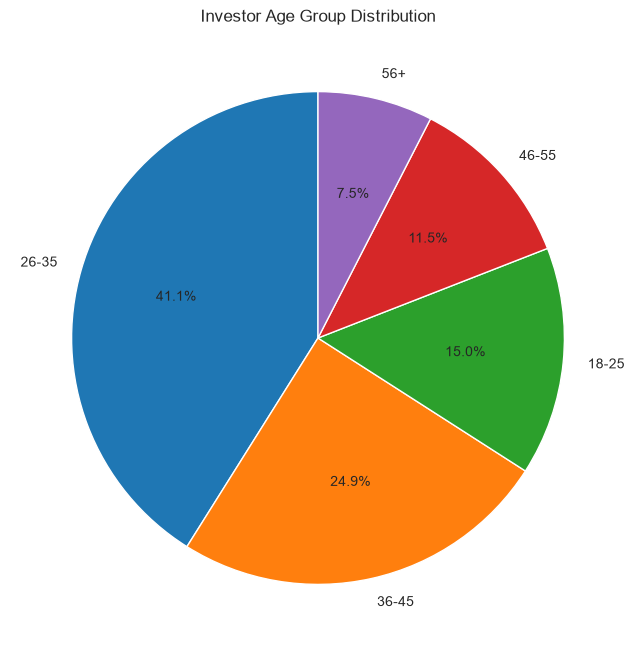

In [50]:
plt.figure(figsize=(8,8))

age_counts =investor["age_group"].value_counts()

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
    )
plt.show()




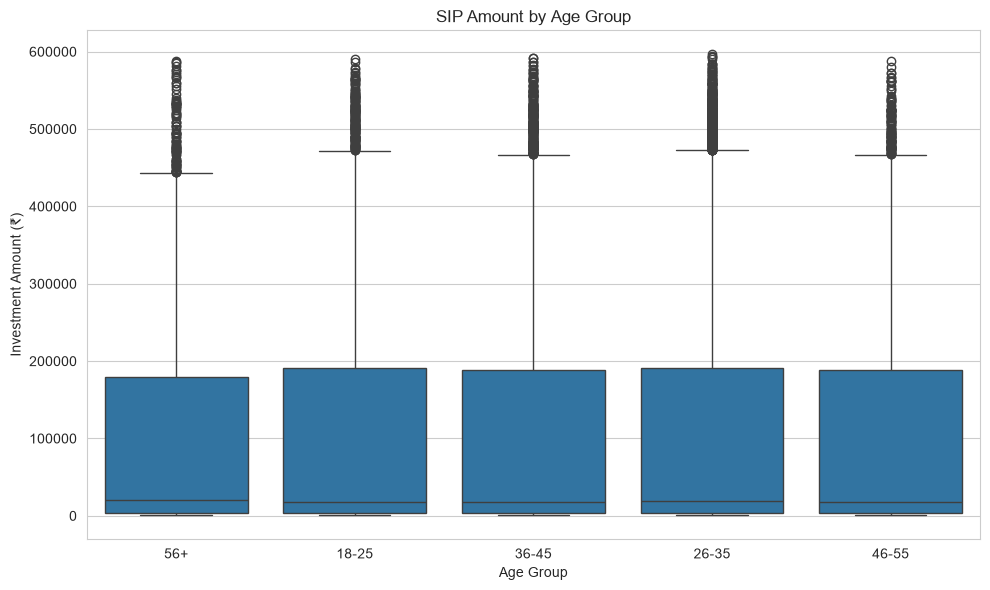

In [51]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../reports/sip_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

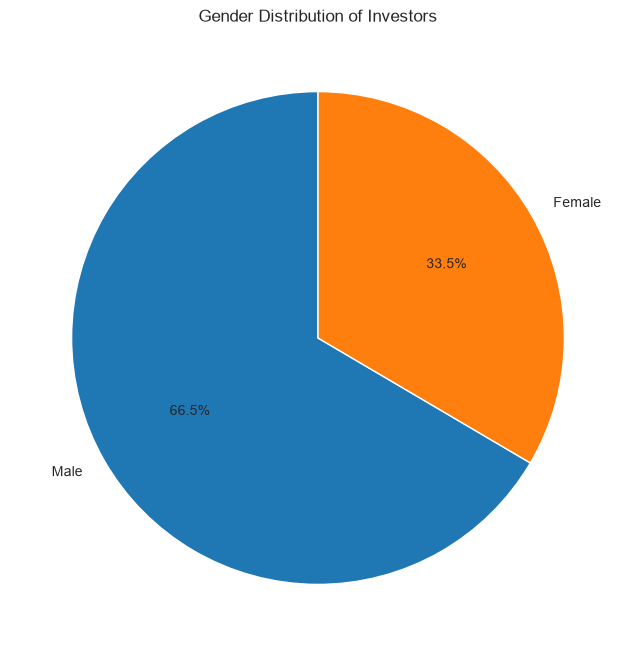

In [52]:
plt.figure(figsize=(8,8))

gender_counts = investor["gender"].value_counts()

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.savefig(
    "../reports/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Task 6: Geographic Distribution

Objective:Analyze the geographic distribution of mutual fund investments using state-wise SIP amounts and city tier (T30 vs B30) participation.

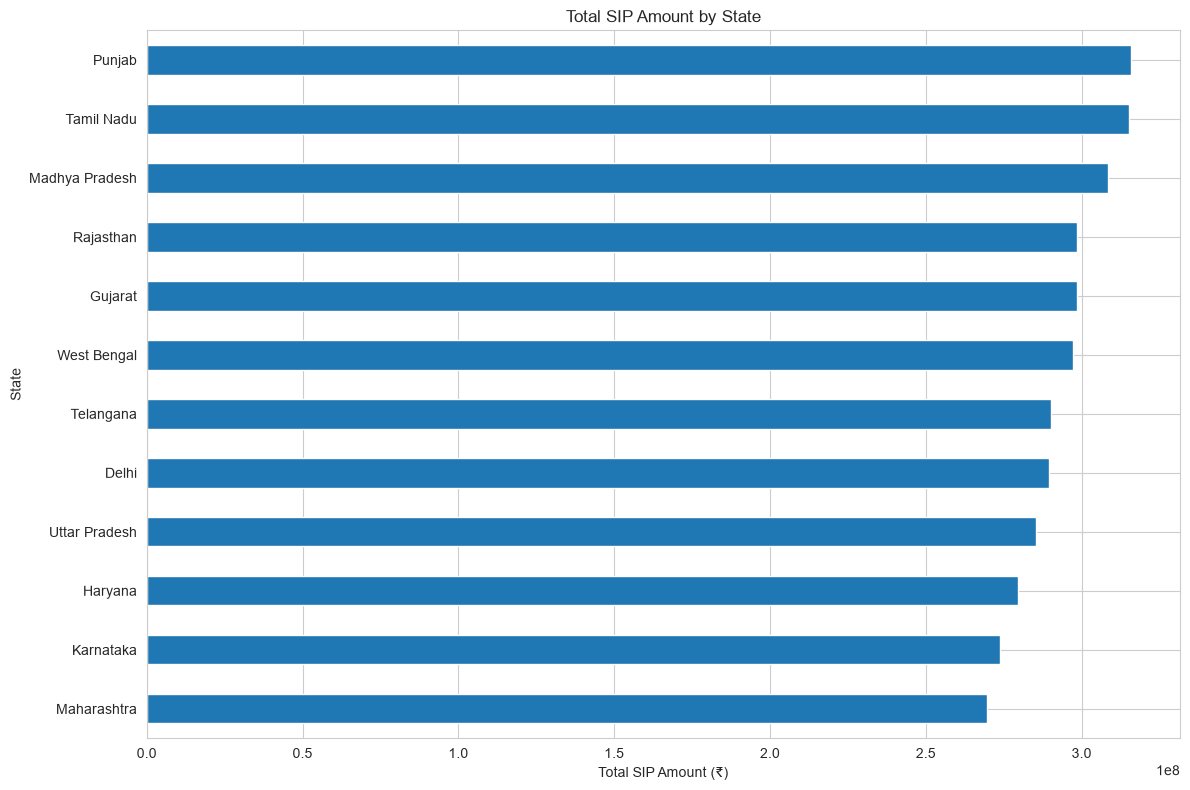

In [53]:
state_sip = investor.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(12,8))

state_sip.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/state_wise_sip_amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

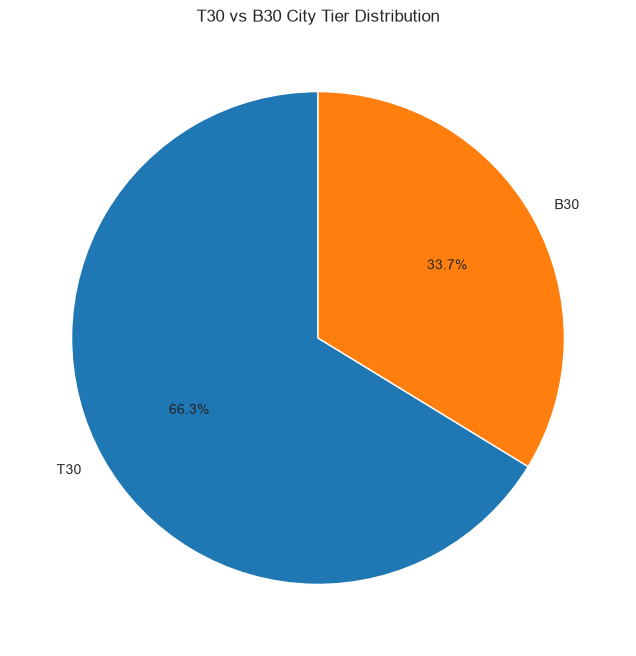

In [54]:
plt.figure(figsize=(8,8))

city_counts = investor["city_tier"].value_counts()

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.savefig(
    "../reports/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Task 7: Folio Count Growth

Objective:Visualize the growth in total mutual fund folios from January 2022 to December 2025 and highlight key milestones.

In [55]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [56]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [57]:
folio.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.1 KB


In [58]:
folio.shape

(21, 6)

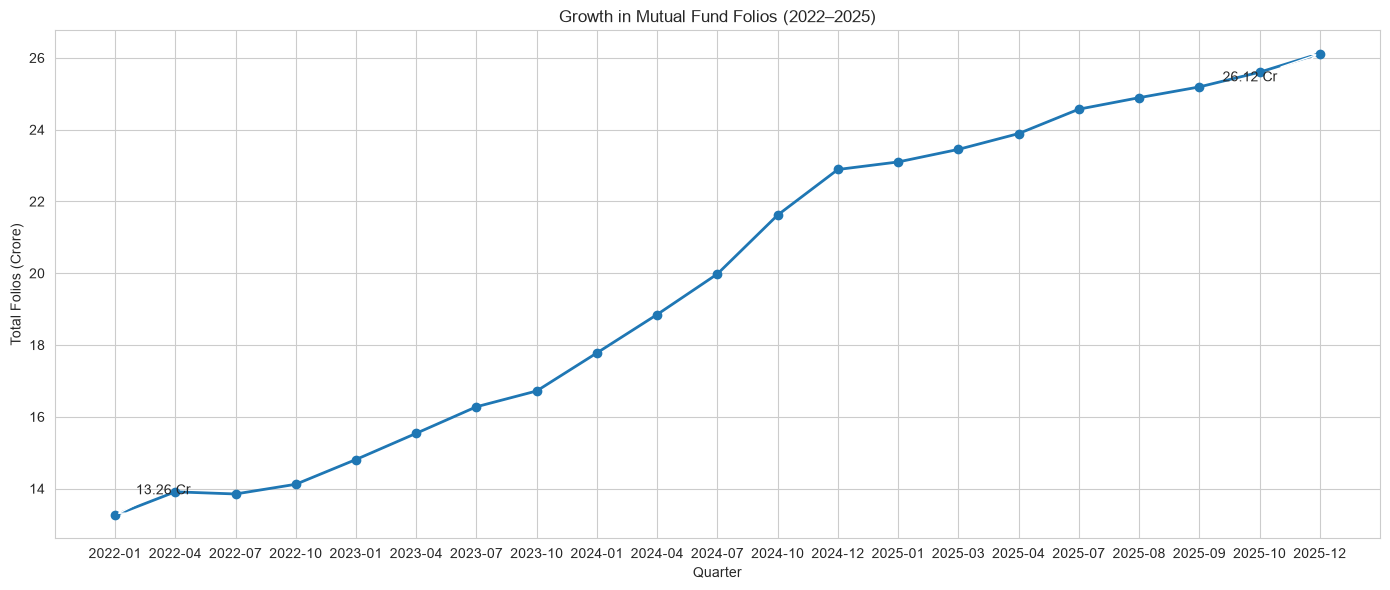

In [59]:
fig, ax = plt.subplots(figsize=(14,6))

ax.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

ax.set_title("Growth in Mutual Fund Folios (2022–2025)")
ax.set_xlabel("Quarter")
ax.set_ylabel("Total Folios (Crore)")
ax.grid(True)

first = folio.iloc[0]
last = folio.iloc[-1]

ax.annotate(
    f"{first['total_folios_crore']} Cr",
    xy=(first["month"], first["total_folios_crore"]),
    xytext=(15,15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

ax.annotate(
    f"{last['total_folios_crore']} Cr",
    xy=(last["month"], last["total_folios_crore"]),
    xytext=(-70,-20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

fig.tight_layout()

# Save BEFORE showing
fig.savefig(
    "../reports/folio_count_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

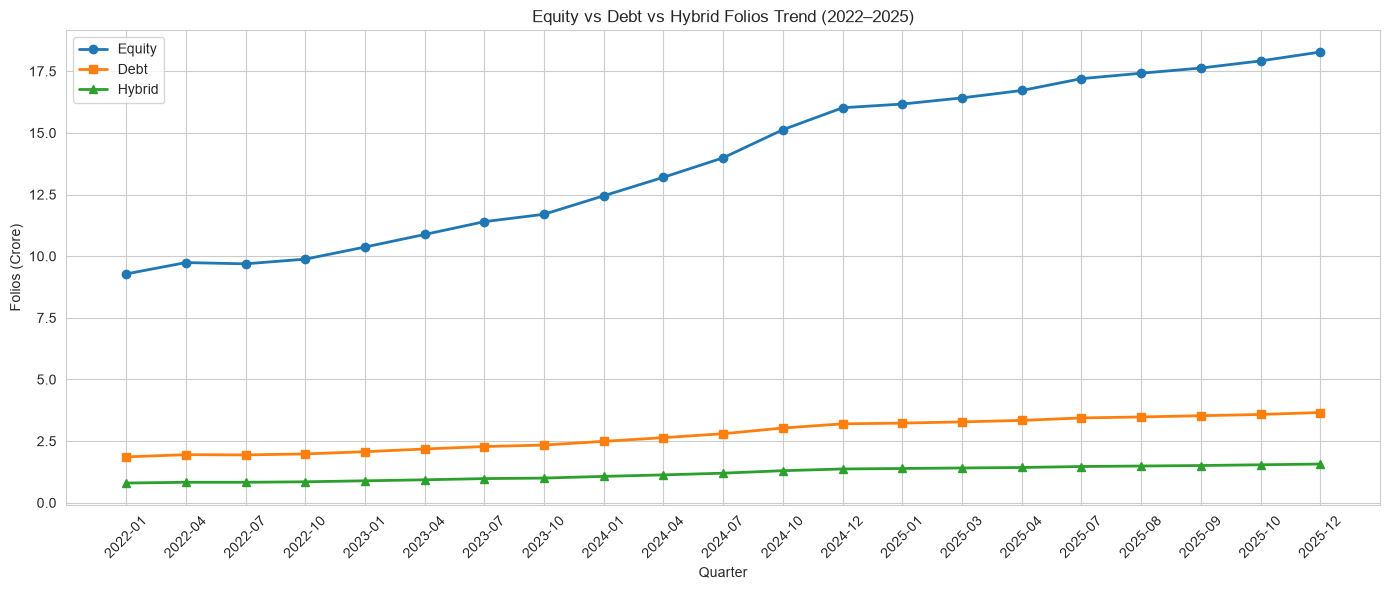

In [60]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["equity_folios_crore"],
    marker="o",
    linewidth=2,
    label="Equity"
)

plt.plot(
    folio["month"],
    folio["debt_folios_crore"],
    marker="s",
    linewidth=2,
    label="Debt"
)

plt.plot(
    folio["month"],
    folio["hybrid_folios_crore"],
    marker="^",
    linewidth=2,
    label="Hybrid"
)

plt.title("Equity vs Debt vs Hybrid Folios Trend (2022–2025)")
plt.xlabel("Quarter")
plt.ylabel("Folios (Crore)")
plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/equity_debt_hybrid_folios.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Task 8: NAV Return Correlation Matrix

Objective:Compute pairwise correlation of daily NAV returns for 10 selected mutual fund schemes and visualize the relationship using a Seaborn heatmap.

In [61]:
nav.head()

,amfi_code,date,nav,scheme_name
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth


In [62]:
nav.columns

Index(['amfi_code', 'date', 'nav', 'scheme_name'], dtype='str')

In [63]:
selected_funds = nav["scheme_name"].drop_duplicates().head(10)

nav_selected = nav[
    nav["scheme_name"].isin(selected_funds)
].copy()

In [64]:
nav_selected["date"] = pd.to_datetime(nav_selected["date"])

In [65]:
nav_pivot = nav_selected.pivot(
    index = "date",
    columns="scheme_name",
    values="nav"
)

In [66]:
daily_returns = nav_pivot.pct_change().dropna()

In [67]:
correlation_matrix = daily_returns.corr()

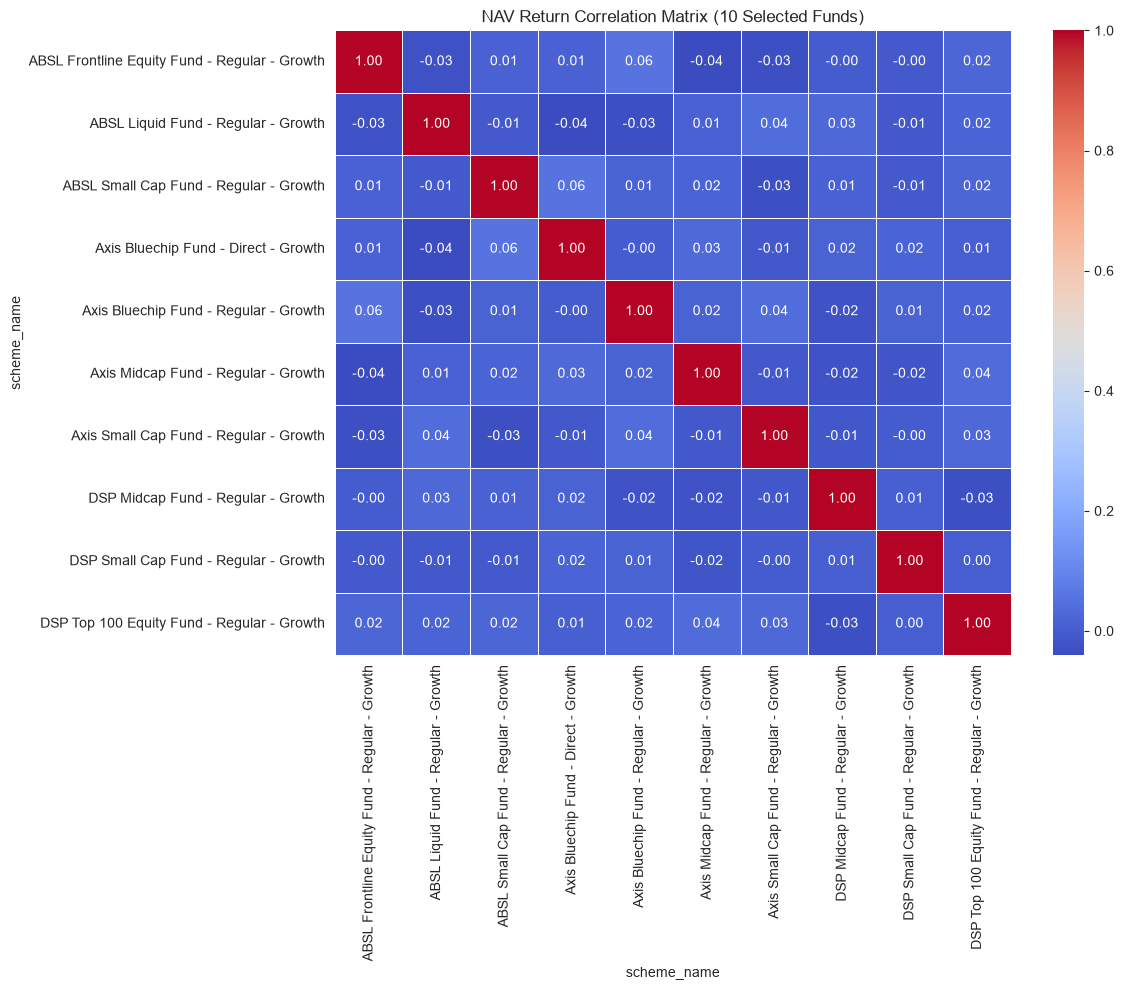

In [68]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("NAV Return Correlation Matrix (10 Selected Funds)")

plt.tight_layout()

plt.savefig(
    "../reports/nav_return_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Task 9: Sector Allocation Donut Chart

Objective:Aggregate sector weights across all equity mutual fund holdings and visualize the portfolio allocation using a donut chart.

In [69]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [70]:
sector_weights = (
    portfolio.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

)

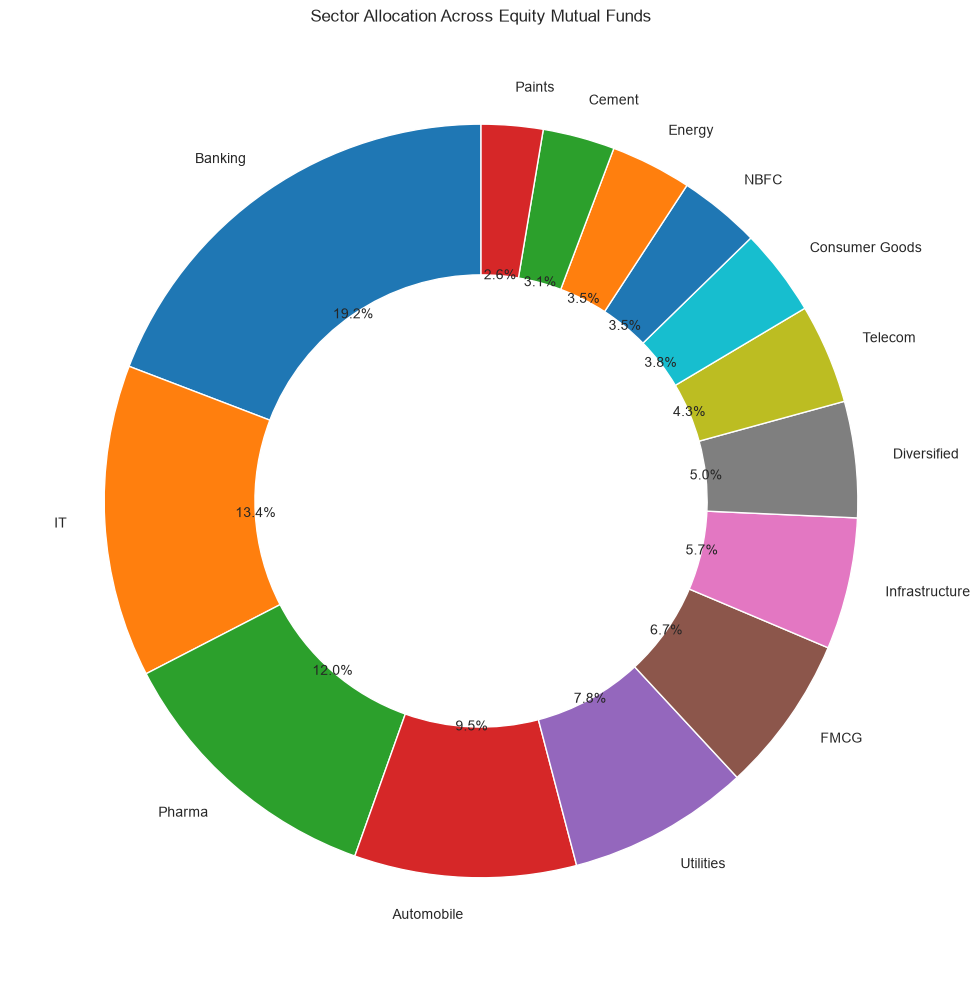

In [71]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.40}
)

plt.title("Sector Allocation Across Equity Mutual Funds")

plt.tight_layout()

plt.savefig(
    "../reports/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

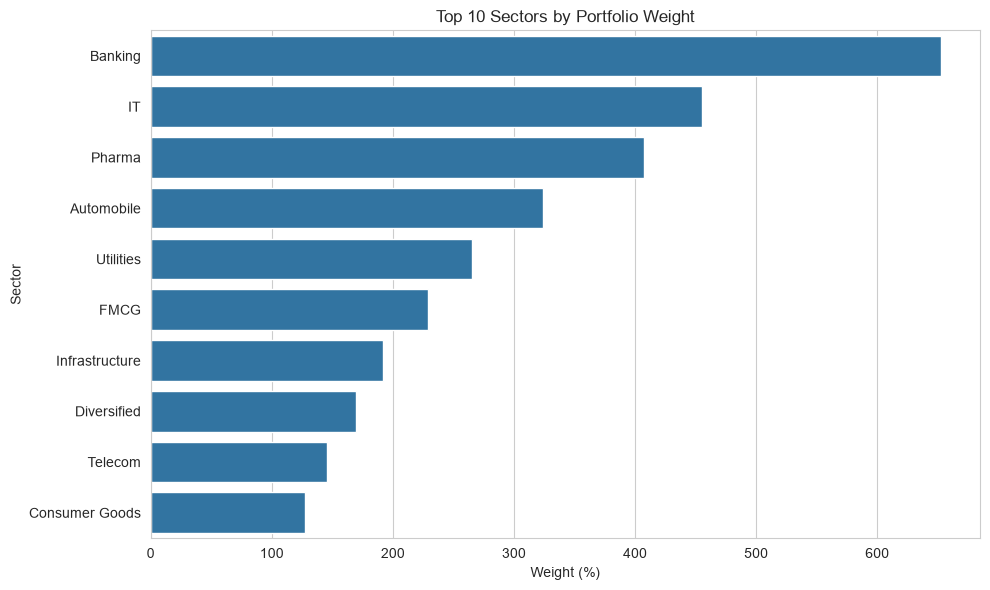

In [72]:
top_sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_sector.values, y=top_sector.index)

plt.title("Top 10 Sectors by Portfolio Weight")
plt.xlabel("Weight (%)")
plt.ylabel("Sector")

plt.tight_layout()
plt.savefig("../reports/top10_sectors.png", dpi=300)
plt.show()

 Key EDA Findings

Insight 1
Daily NAV values showed an overall upward trend from 2022–2026, with strong growth during the 2023 bull market.

Insight 2
SBI Mutual Fund maintained one of the highest Assets Under Management among all fund houses during 2022–2025

Insight 3
Monthly SIP inflows increased steadily and reached their highest value in December 2025.

Insight 4
Net inflows varied across mutual fund categories, with equity-oriented categories generally attracting stronger investor interest.

Insight 5
The age group distribution indicates that younger and middle-aged investors contribute a significant share of mutual fund participation.

Insight 6
Investment amounts differ across age groups, showing variation in SIP contribution patterns. 

Insight 7
State-wise analysis highlights regional differences in mutual fund investments, while T30 cities contribute a substantial share of investors. *
Insight 8
Mutual fund folio counts increased consistently between 2022 and 2025, reflecting growing investor participation. 

Insight 9
Several mutual fund schemes exhibit strong positive correlations in daily NAV returns, while others provide diversification opportunities. 

Insight 10
Sector allocation analysis shows that equity mutual funds maintain diversified exposure across multiple industries. *